In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# Load credit risk dataset
df = pd.read_csv("../dataset/credit_risk_dataset.csv")

# Display first 5 rows
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,...,num_late_payments_24m,num_hard_inquiries_6m,existing_monthly_debt,savings_balance,has_co_applicant,monthly_income,est_monthly_payment,total_interest_cost,debt_to_income_ratio,credit_history_to_age_ratio
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,...,1.0,4.0,331.0,6490.0,0,4916.67,851.50,16090.24,0.241,0.136
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,...,1.0,1.0,91.0,3004.0,0,800.00,46.67,120.15,0.172,0.095
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,...,0.0,NaN,235.0,0.0,0,800.00,124.78,1986.57,0.450,0.120
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,...,1.0,0.0,1171.0,7516.0,0,5458.33,836.88,15212.74,0.368,0.087
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,...,3.0,1.0,522.0,2538.0,0,4533.33,1200.81,8229.23,0.380,0.167


In [3]:
# Check number of rows and columns
print("Number of Records:", df.shape[0])
print("Number of Attributes:", df.shape[1])

Number of Records: 32581
Number of Attributes: 30


In [4]:
# Display all feature names
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length',
       'loan_term_months', 'employment_type', 'education_level',
       'marital_status', 'num_dependents', 'credit_score',
       'credit_utilization_pct', 'num_open_accounts', 'num_late_payments_24m',
       'num_hard_inquiries_6m', 'existing_monthly_debt', 'savings_balance',
       'has_co_applicant', 'monthly_income', 'est_monthly_payment',
       'total_interest_cost', 'debt_to_income_ratio',
       'credit_history_to_age_ratio'],
      dtype='str')

In [5]:
#check data information(missing things and data types)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 30 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   person_age                   32581 non-null  int64  
 1   person_income                32581 non-null  int64  
 2   person_home_ownership        32581 non-null  str    
 3   person_emp_length            31686 non-null  float64
 4   loan_intent                  32581 non-null  str    
 5   loan_grade                   32581 non-null  str    
 6   loan_amnt                    32581 non-null  int64  
 7   loan_int_rate                29465 non-null  float64
 8   loan_status                  32581 non-null  int64  
 9   loan_percent_income          32581 non-null  float64
 10  cb_person_default_on_file    32581 non-null  str    
 11  cb_person_cred_hist_length   32581 non-null  int64  
 12  loan_term_months             32581 non-null  int64  
 13  employment_type            

In [6]:
# Statistical summary of numerical features
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,loan_term_months,num_dependents,...,num_late_payments_24m,num_hard_inquiries_6m,existing_monthly_debt,savings_balance,has_co_applicant,monthly_income,est_monthly_payment,total_interest_cost,debt_to_income_ratio,credit_history_to_age_ratio
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000,32581.000000,31684.000000,...,31602.000000,31621.000000,30838.000000,2.938200e+04,32581.000000,32581.000000,29465.000000,29465.000000,27885.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211,42.193548,0.272630,...,0.442504,1.094779,975.938388,3.125579e+04,0.115589,5506.237391,290.923189,2294.749253,0.223891,0.194686
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001,14.220175,0.616735,...,0.837970,1.134432,1601.063394,2.880973e+05,0.319736,5165.259921,200.552879,2335.335878,0.147040,0.093528
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000,12.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000e+00,0.000000,333.330000,16.080000,28.780000,0.001000,0.014000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000,36.000000,0.000000,...,0.000000,0.000000,197.000000,4.737250e+03,0.000000,3208.330000,155.050000,753.210000,0.116000,0.125000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000,36.000000,0.000000,...,0.000000,1.000000,501.000000,1.240050e+04,0.000000,4583.330000,242.620000,1497.120000,0.186000,0.174000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000,60.000000,0.000000,...,1.000000,2.000000,1232.000000,3.050200e+04,0.000000,6600.000000,373.040000,2994.640000,0.298000,0.260000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000,60.000000,5.000000,...,7.000000,8.000000,96655.000000,4.800000e+07,1.000000,500000.000000,3190.340000,20765.770000,0.910000,0.588000


In [7]:
# Display categorical columns
categorical_columns = df.select_dtypes(include='object').columns
categorical_columns

Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file', 'employment_type', 'education_level',
       'marital_status'],
      dtype='str')

In [8]:
# Count unique values in each categorical column
for col in categorical_columns:
    print("\nColumn:", col)
    print(df[col].value_counts())


Column: person_home_ownership
person_home_ownership
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107
Name: count, dtype: int64

Column: loan_intent
loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64

Column: loan_grade
loan_grade
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64
Name: count, dtype: int64

Column: cb_person_default_on_file
cb_person_default_on_file
N    26836
Y     5745
Name: count, dtype: int64

Column: employment_type
employment_type
Full-time        20055
Self-employed     4418
Part-time         3794
Contract          2237
Unemployed         864
Retired            317
Name: count, dtype: int64

Column: education_level
education_level
Bachelor       11661
High School     6775
Diploma         5539
Master          5203
Doctorate       1508
Name: count, dtype: int64

Column: marit

In [9]:
# Check target variable distribution
df['loan_status'].value_counts()

loan_status
0    25473
1     7108
Name: count, dtype: int64

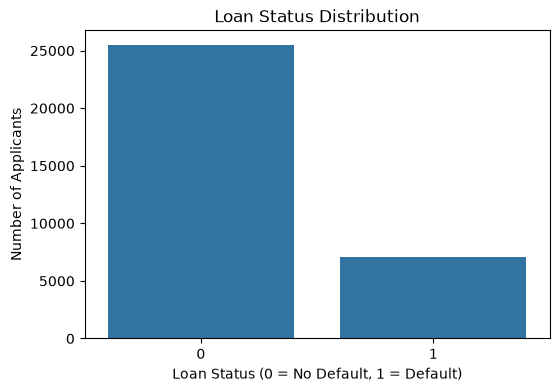

In [10]:
# Plot target distribution
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='loan_status'
)

plt.title("Loan Status Distribution")
plt.xlabel("Loan Status (0 = No Default, 1 = Default)")
plt.ylabel("Number of Applicants")

plt.show()

In [11]:
# Calculate target class percentages
loan_status_percentage = df['loan_status'].value_counts(normalize=True) * 100

loan_status_percentage

loan_status
0    78.183604
1    21.816396
Name: proportion, dtype: float64

In [13]:
# Missing value analysis
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

person_emp_length          895
loan_int_rate             3116
employment_type            896
education_level           1895
marital_status             604
num_dependents             897
credit_score              1296
credit_utilization_pct     972
num_open_accounts          644
num_late_payments_24m      979
num_hard_inquiries_6m      960
existing_monthly_debt     1743
savings_balance           3199
est_monthly_payment       3116
total_interest_cost       3116
debt_to_income_ratio      4696
dtype: int64

In [14]:
# Check duplicate records
duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 165


In [15]:
# Display duplicate records
df[df.duplicated()].head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,...,num_late_payments_24m,num_hard_inquiries_6m,existing_monthly_debt,savings_balance,has_co_applicant,monthly_income,est_monthly_payment,total_interest_cost,debt_to_income_ratio,credit_history_to_age_ratio
15975,23,42000,RENT,5.0,VENTURE,B,6000,9.99,0,0.14,...,0.0,0.0,0.0,9510.0,0,3500.00,193.57,968.70,0.055,0.174
15989,23,90000,MORTGAGE,7.0,EDUCATION,B,8000,10.36,0,0.09,...,0.0,1.0,2631.0,114154.0,0,7500.00,259.49,1341.70,0.385,0.130
15995,24,48000,MORTGAGE,4.0,MEDICAL,A,4000,5.42,0,0.08,...,0.0,0.0,1134.0,12776.0,0,4000.00,176.24,229.73,0.328,0.167
16025,24,10000,RENT,8.0,PERSONAL,A,3000,7.90,1,0.30,...,0.0,1.0,20.0,8195.0,0,833.33,60.69,641.14,0.097,0.125
16028,23,100000,MORTGAGE,7.0,EDUCATION,A,15000,7.88,0,0.15,...,0.0,1.0,1012.0,14954.0,0,8333.33,469.22,1891.76,0.178,0.174


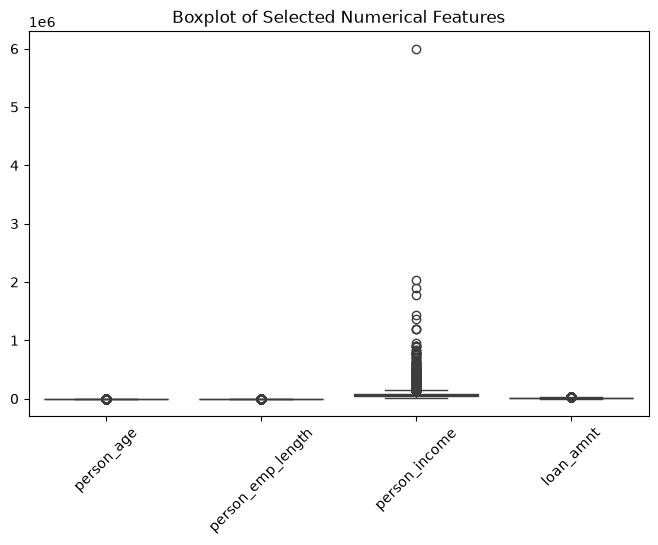

In [16]:
# Boxplot for detecting outliers in numerical features
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df[['person_age',
             'person_emp_length',
             'person_income',
             'loan_amnt']]
)

plt.title("Boxplot of Selected Numerical Features")

plt.xticks(rotation=45)

plt.show()

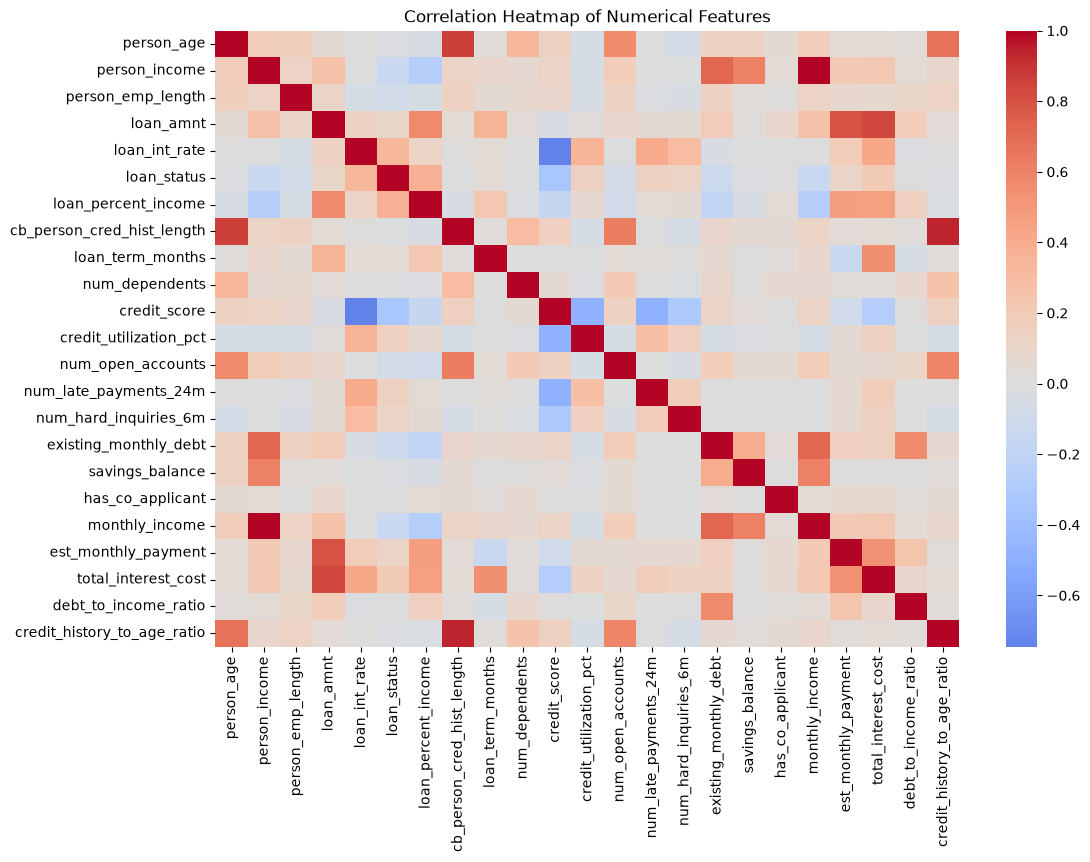

In [17]:
# Correlation analysis
plt.figure(figsize=(12,8))

correlation = df.select_dtypes(include=['int64','float64']).corr()

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numerical Features")

plt.show()